<a href="https://colab.research.google.com/github/aramrdz06/Actividad-2-computacion-cuantica/blob/main/computacion_cuantica_practica_de_clase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pr(0) = (pr0:.2%)
Pr(1) = (pr1:.2%)


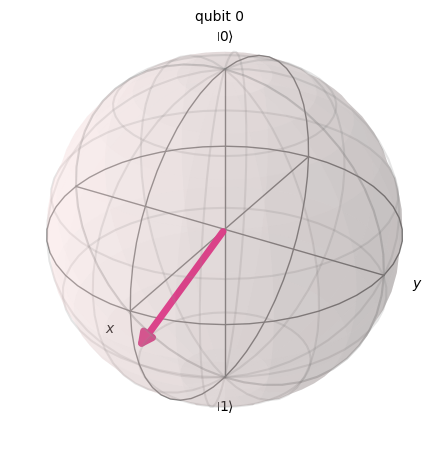

In [ ]:
#!pip install qiskit qiskit-aer matplotlib pylatexenc
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import sqrt

# ANTES(creado)
#aqc = QuantumCircuit(1)
#estado_antes = Statevector(qc)
#splot_bloch_multivector(estado_antes)
# DESPUES: Hadamard P
#qc.h(0)
#estado_despues = Statevector(qc)
#plot_bloch_multivector(estado_despues)

alpha, beta = 0.6, 0.8
qc = QuantumCircuit(1)
qc.initialize([alpha, beta], 0)

estado_antes = Statevector(qc)
pr0, pr1 = estado_antes.probabilities()

print(f"Pr(0) = (pr0:.2%)")
print(f"Pr(1) = (pr1:.2%)")
plot_bloch_multivector(Statevector(qc))

Pr(0) = (pr0:.2%)
Pr(1) = (pr1:.2%)


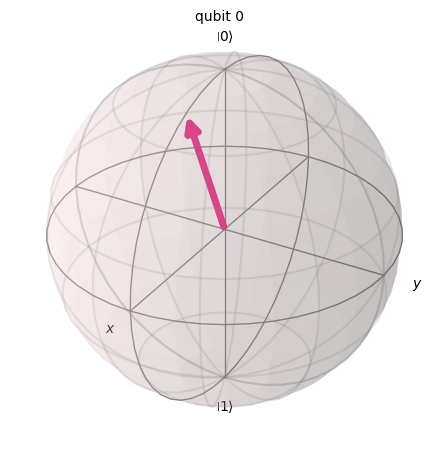

In [ ]:
#!pip install qiskit qiskit-aer matplotlib pylatexenc
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import math

# ANTES(creado)
#aqc = QuantumCircuit(1)
#estado_antes = Statevector(qc)
#splot_bloch_multivector(estado_antes)
# DESPUES: Hadamard P
#qc.h(0)
#estado_despues = Statevector(qc)
#plot_bloch_multivector(estado_despues)
grad=12
rad = math.radians(grad)
alpha = math.cos(rad)
beta = math.sin(rad)
qc = QuantumCircuit(1)
qc.initialize([alpha, beta], 0)

estado_antes = Statevector(qc)
pr0, pr1 = estado_antes.probabilities()

print(f"Pr(0) = (pr0:.2%)")
print(f"Pr(1) = (pr1:.2%)")
plot_bloch_multivector(Statevector(qc))


In [2]:
#2.1
#!pip install qiskit qiskit-aer matplotlib ipywidgets -q

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
from math import radians, sin, cos
import ipywidgets as widgets
from IPython.display import display

# widgets en Colab
from google.colab import output
output.enable_custom_widget_manager()


def actualizar(theta, phi):

    # Convertir grados a radianes
    t = radians(theta)
    p = radians(phi)

    # Estado del qubit:
    # |ψ> = cos(θ/2)|0> + e^(iφ)sin(θ/2)|1>
    alpha = cos(t / 2)

    beta = (
        sin(t / 2) * cos(p)
        + 1j * sin(t / 2) * sin(p)
    )

    #circuito
    qc = QuantumCircuit(1)
    qc.initialize([alpha, beta], 0)

    # Estado
    estado = Statevector(qc)

    # Probabilidades
    pr0, pr1 = estado.probabilities()

    # Coordenadas del vector en la esfera de Bloch
    x = sin(t) * cos(p)
    y = sin(t) * sin(p)
    z = cos(t)


    # ESFERA DE BLOCH
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='3d')

    # esfera
    u = np.linspace(0, 2 * np.pi, 50)
    v = np.linspace(0, np.pi, 25)

    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones(np.size(u)), np.cos(v))

    ax.plot_surface(
        xs, ys, zs,
        alpha=0.15,
        edgecolor='gray',
        linewidth=0.3
    )

    # Ejes
    ax.plot([-1, 1], [0, 0], [0, 0], linewidth=1)
    ax.plot([0, 0], [-1, 1], [0, 0], linewidth=1)
    ax.plot([0, 0], [0, 0], [-1, 1], linewidth=1)

    # Vector del qubit
    ax.quiver(
        0, 0, 0,
        x, y, z,
        color='red',
        linewidth=3,
        arrow_length_ratio=0.12
    )

    # Puntos de los estados |0> y |1>
    ax.scatter(0, 0, 1, s=60)
    ax.scatter(0, 0, -1, s=60)

    # Etiquetas
    ax.text(0, 0, 1.15, '|0⟩', fontsize=14)
    ax.text(0, 0, -1.15, '|1⟩', fontsize=14)

    ax.text(1.1, 0, 0, 'X', fontsize=12)
    ax.text(0, 1.1, 0, 'Y', fontsize=12)
    ax.text(0, 0, 1.1, 'Z', fontsize=12)

    # Configuración
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    ax.set_title(
        f'Esfera de Bloch\nθ = {theta}°   φ = {phi}°',
        fontsize=14
    )

    # Mantener proporciones
    ax.set_box_aspect([1, 1, 1])

    plt.show()

    # Información
    print(f"θ = {theta}°")
    print(f"φ = {phi}°")
    print()
    print(f"Pr(0) = {pr0:.2%}")
    print(f"Pr(1) = {pr1:.2%}")
    print()
    print("Estado:")
    print(estado)



# SLIDER THETA
slider_theta = widgets.IntSlider(
    value=90,
    min=0,
    max=180,
    step=1,
    description='θ:',
    continuous_update=True,
    style={'description_width': '30px'},
    layout=widgets.Layout(width='500px')
)


# SLIDER PHI
slider_phi = widgets.IntSlider(
    value=0,
    min=0,
    max=360,
    step=1,
    description='φ:',
    continuous_update=True,
    style={'description_width': '30px'},
    layout=widgets.Layout(width='500px')
)


# muestra los resultados

ui = widgets.VBox([
    slider_theta,
    slider_phi
])

out = widgets.interactive_output(
    actualizar,
    {
        'theta': slider_theta,
        'phi': slider_phi
    }
)

display(ui)
display(out)

Output()

In [ ]:
#2.2
import numpy as np

# --- Parte 1: producto interno (verifica lo que calculaste a mano) ---
ket0 = np.array([1, 0])
ket1 = np.array([0, 1])
mas = np.array([1, 1]) / np.sqrt(2)       # |+⟩ = (|0⟩+|1⟩)/√2
menos = np.array([1, -1]) / np.sqrt(2)    # |−⟩ = (|0⟩−|1⟩)/√2

print("⟨0|1⟩ =", np.vdot(ket0, ket1))
print("⟨0|+⟩ =", round(np.vdot(ket0, mas), 3))
print("⟨−|+⟩ =", round(np.vdot(menos, mas), 3))

# --- Parte 2: producto tensorial (combinar 2 qubits) ---
estado_conjunto = np.kron(mas, mas)
print("\n|+⟩⊗|+⟩ =", np.round(estado_conjunto, 3))

⟨0|1⟩ = 0
⟨0|+⟩ = 0.707
⟨−|+⟩ = 0.0

|+⟩⊗|+⟩ = [0.5 0.5 0.5 0.5]


X -> Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


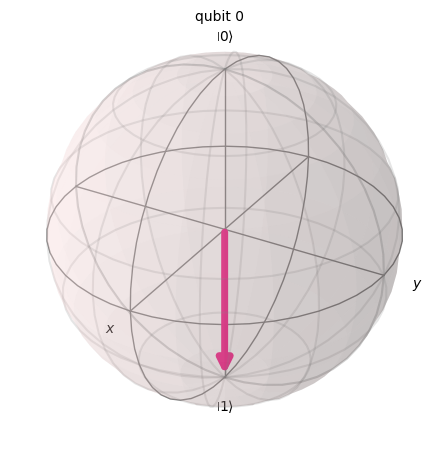

Y -> Statevector([0.+0.j, 0.+1.j],
            dims=(2,))


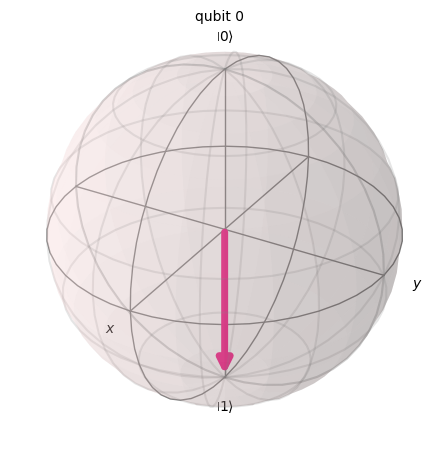

Z -> Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


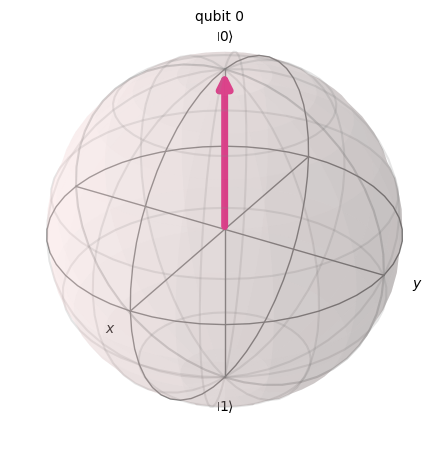

H -> Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


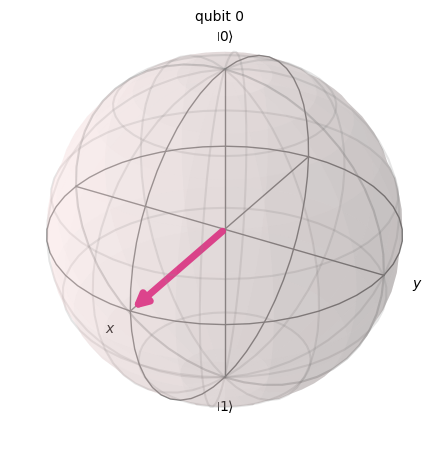

S -> Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


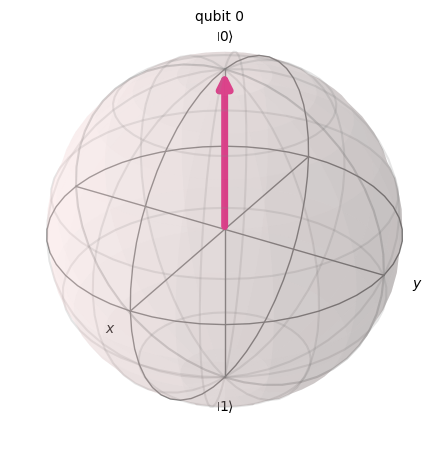

T -> Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


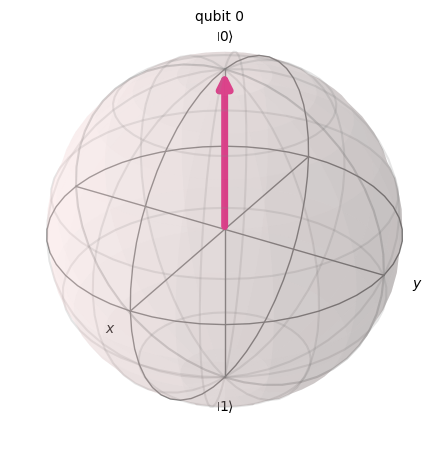

In [ ]:
#2.3
# Instala Qiskit si no está disponible en el entorno
!pip install -q qiskit

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

compuertas = {"X": "x", "Y": "y", "Z": "z", "H": "h", "S": "s", "T": "t"}

for nombre, metodo in compuertas.items():
    qc = QuantumCircuit(1)
    getattr(qc, metodo)(0)  # aplica la compuerta que toque en este ciclo[cite: 1]
    print(nombre, "->", Statevector(qc))
    display(plot_bloch_multivector(Statevector(qc)))